In [1]:
import matplotlib.pyplot as plt
import numpy as np
import util
import pandas as pd
from classical_strategies import baseload
from tabulate import tabulate

In [4]:
config = util.load_config('../test/a31cccc7-7bab-47a3-a7dc-572aef7b6a5b/config_a31cccc7-7bab-47a3-a7dc-572aef7b6a5b.yaml')
dataset = util.load_dataset_no_split_with_loads('../../data/processed/dataset_2018-21_withloads.csv', config)

/Users/zachl/Desktop/WindEnergyForecasting/strategy_model/src/util.py:120: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = threshold


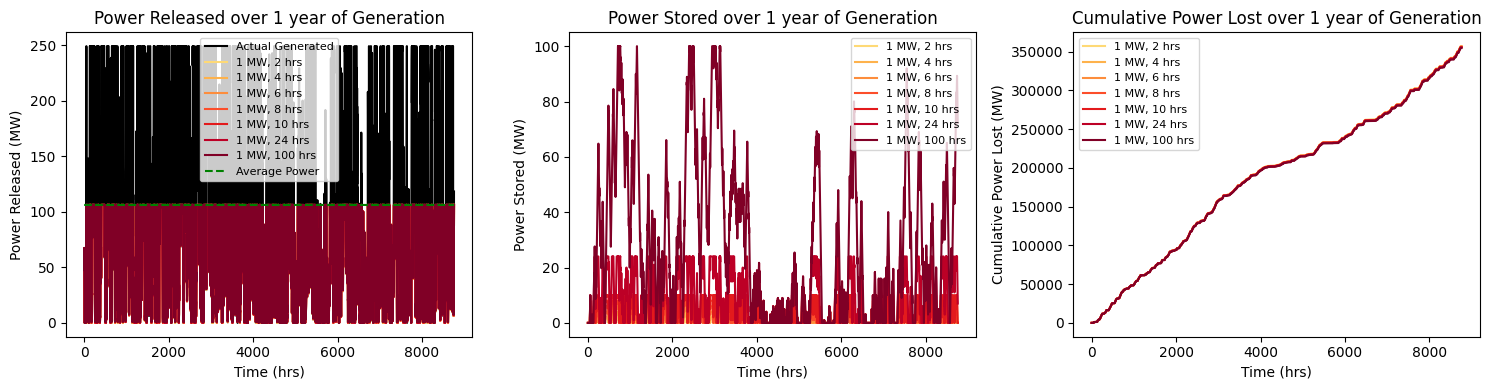

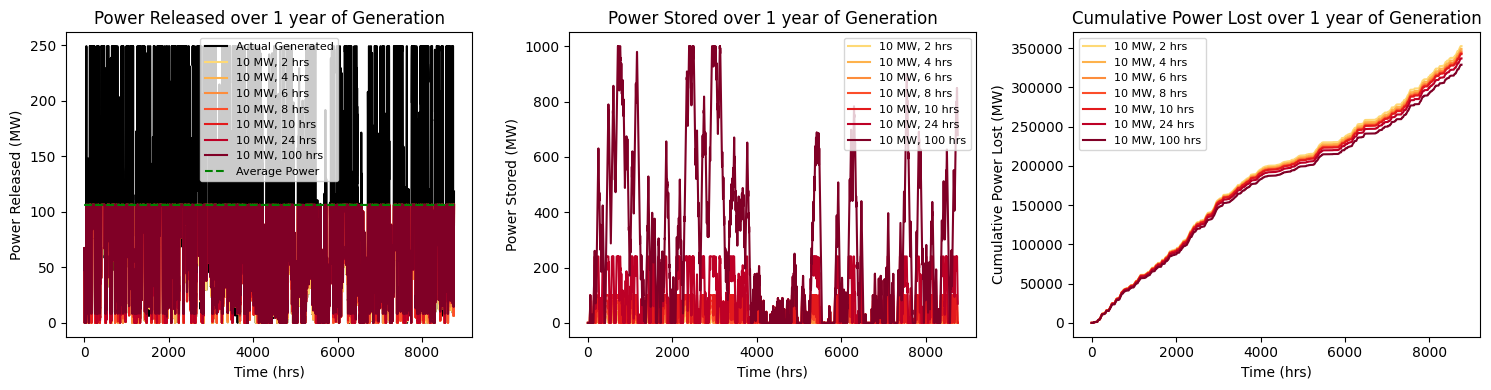

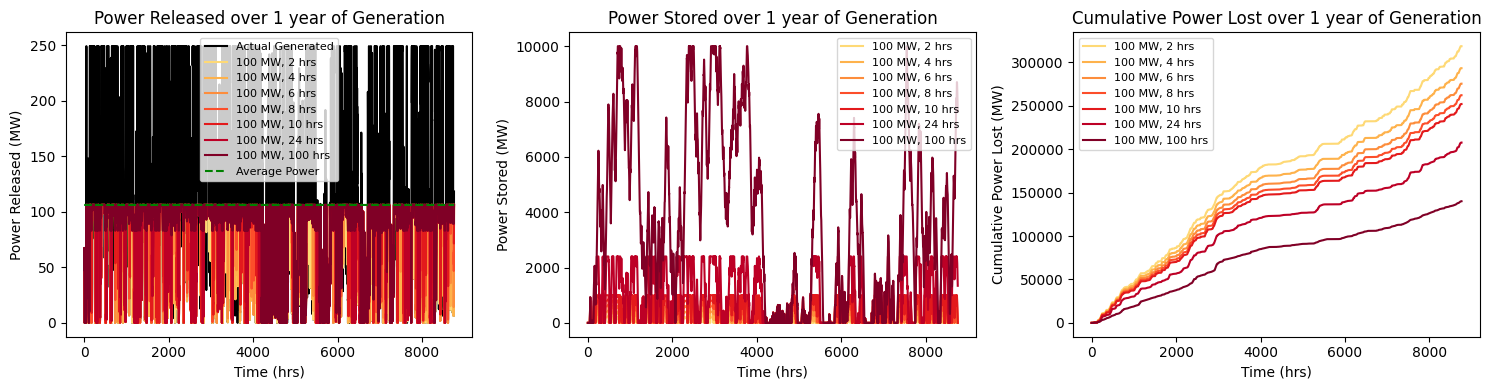

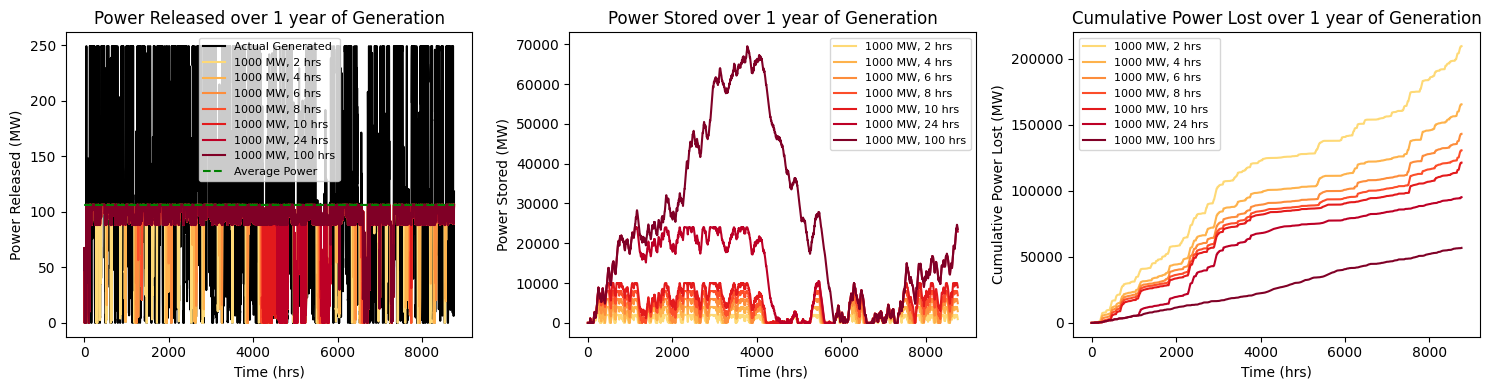

In [ ]:
def explore_storage_type(type):
    scale = '1 year'
    upper_bound = 24 * 365

    data = dataset[:upper_bound, :]
    power = data[:,0].detach().cpu().numpy().squeeze()
    price = data[:,1].detach().cpu().numpy().squeeze()
    x = np.arange(0, len(power))
    avg_power = np.repeat(np.mean(power), len(x))

    ratings = [1, 10, 100, 1000]
    durations = [2, 4, 6, 8, 10, 24, 100]

    R = len(ratings)
    D = len(durations)

    vfs = np.zeros((R,D))
    coves = np.zeros((R,D))

    for i in range(R):
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
        cmap = plt.get_cmap('YlOrRd', D + 2)

        ax1.plot(x, power, 'black', label='Actual Generated')

        for j in range(D):
            rating = ratings[i]
            duration = durations[j]
            capacity = rating * duration

            baseload_released, baseload_stored, baseload_losses = baseload(power, rating, capacity, util.get_rte(type))

            vfs[i,j] = util.value_factor(baseload_released, price)
            coves[i,j] = util.cove(baseload_released, price, type, rating, duration)
            
            ax1.plot(x, baseload_released, color=cmap(j + 2), label=f'{rating} MW, {duration} hrs')
            ax2.plot(x, baseload_stored, color=cmap(j + 2), label=f'{rating} MW, {duration} hrs')
            ax3.plot(x, np.cumsum(baseload_losses), color=cmap(j + 2), label=f'{rating} MW, {duration} hrs')

        ax1.plot(x, avg_power, '--g', label='Average Power')
        # Show plots
        ax1.set_xlabel('Time (hrs)')
        ax1.set_ylabel('Power Released (MW)')
        ax1.set_title(f'Power Released over {scale} of Generation')
        ax1.legend(fontsize=8)

        ax2.set_xlabel('Time (hrs)')
        ax2.set_ylabel('Power Stored (MW)')
        ax2.set_title(f'Power Stored over {scale} of Generation')
        ax2.legend(fontsize=8)

        ax3.set_xlabel('Time (hrs)')
        ax3.set_ylabel('Cumulative Power Lost (MW)')
        ax3.set_title(f'Cumulative Power Lost over {scale} of Generation')
        ax3.legend(fontsize=8)
        
        plt.tight_layout()
        plt.show()

    for i in range(R):
        print(f'{type} Performance using Rating {ratings[i]} MW')
        metrics = {
            'Duration': durations,
            'VF': vfs[i,:],
            'COVE': coves[i,:]
        }
        df = pd.DataFrame(metrics)
        print(tabulate(df, headers='keys', tablefmt='psql'))

    min_cove = np.min(coves)
    max_vf = np.max(vfs)
    print(f'Minimum COVE: {min_cove} (w/ {ratings[np.where(coves == min_cove)[0][0]]} MW, {durations[np.where(coves == min_cove)[1][0]]} hrs)')
    print(f'Maximum VF: {max_vf} (w/ {ratings[np.where(vfs == max_vf)[0][0]]} MW, {durations[np.where(vfs == max_vf)[1][0]]} hrs)')

In [10]:
strategy_names = ["Raw", ""]
for i in range(R):
    print(f'Performance using Rating {ratings[i]} MW battery')
    metrics = {
        'Duration': durations,
        'VF': vfs[i,:],
        'COVE': coves[i,:]
    }
    df = pd.DataFrame(metrics)
    print(tabulate(df, headers='keys', tablefmt='psql'))

min_cove = np.min(coves)
max_vf = np.max(vfs)
print(f'Minimum COVE: {min_cove} (w/ {ratings[np.where(coves == min_cove)[0][0]]} MW, {durations[np.where(coves == min_cove)[1][0]]} hrs)')
print(f'Maximum VF: {max_vf} (w/ {ratings[np.where(vfs == max_vf)[0][0]]} MW, {durations[np.where(vfs == max_vf)[1][0]]} hrs)')

Performance using Rating 1 MW battery
+----+------------+----------+-------------+
|    |   Duration |       VF |        COVE |
|----+------------+----------+-------------|
|  0 |          2 | 0.755263 | 8.68869e-05 |
|  1 |          4 | 0.755625 | 8.6789e-05  |
|  2 |          6 | 0.756056 | 8.66945e-05 |
|  3 |          8 | 0.756543 | 8.66053e-05 |
|  4 |         10 | 0.756672 | 8.6568e-05  |
|  5 |         24 | 0.75719  | 8.64258e-05 |
|  6 |        100 | 0.757759 | 8.62482e-05 |
+----+------------+----------+-------------+
Performance using Rating 10 MW battery
+----+------------+----------+-------------+
|    |   Duration |       VF |        COVE |
|----+------------+----------+-------------|
|  0 |          2 | 0.757292 | 8.59628e-05 |
|  1 |          4 | 0.760941 | 8.50188e-05 |
|  2 |          6 | 0.76529  | 8.41161e-05 |
|  3 |          8 | 0.769749 | 8.33237e-05 |
|  4 |         10 | 0.770926 | 8.2989e-05  |
|  5 |         24 | 0.775812 | 8.17124e-05 |
|  6 |        100 | 0.7

In [ ]:
scale = '1 year'
upper_bound = 24 * 30

data = dataset[:upper_bound, :]
power = data[:,0].detach().cpu().numpy().squeeze()
price = data[:,1].detach().cpu().numpy().squeeze()
x = np.arange(0, len(power))
avg_power = np.repeat(np.mean(power), len(x))

ratings = [100, 1000]
durations = [4, 10, 24, 100]

R = len(ratings)
D = len(durations)

vfs = np.zeros((R,D))
coves = np.zeros((R,D))

for i in range(R):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    cmap = plt.get_cmap('YlOrRd', D + 2)

    ax1.plot(x, power, 'black', label='Actual Generated')

    for j in range(D):
        rating = ratings[i]
        duration = durations[j]
        capacity = rating * duration

        baseload_released, baseload_stored, baseload_losses = baseload(power, rating, capacity, util.get_rte('caes'))

        vfs[i,j] = util.value_factor(baseload_released, price)
        coves[i,j] = util.cove(baseload_released, price, rating, duration)
        
        ax1.plot(x, baseload_released, color=cmap(j + 2), label=f'{rating} MW, {duration} hrs')
        ax2.plot(x, baseload_stored, color=cmap(j + 2), label=f'{rating} MW, {duration} hrs')
        ax3.plot(x, np.cumsum(baseload_losses), color=cmap(j + 2), label=f'{rating} MW, {duration} hrs')

    ax1.plot(x, avg_power, '--g', label='Average Power')
    # Show plots
    ax1.set_xlabel('Time (hrs)')
    ax1.set_ylabel('Power Released (MW)')
    ax1.set_title(f'Power Released over {scale} of Generation')
    ax1.legend(fontsize=8)

    ax2.set_xlabel('Time (hrs)')
    ax2.set_ylabel('Power Stored (MW)')
    ax2.set_title(f'Power Stored over {scale} of Generation')
    ax2.legend(fontsize=8)

    ax3.set_xlabel('Time (hrs)')
    ax3.set_ylabel('Cumulative Power Lost (MW)')
    ax3.set_title(f'Cumulative Power Lost over {scale} of Generation')
    ax3.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()
    